# Модели регрессии

In [177]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

print(type(california))
print(california.keys())
print(type(california.data), type(california.target))
print(california.data.shape, california.target.shape)

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(20640, 8) (20640,)


In [178]:

data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [179]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [180]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [181]:
y = data['Price']
X = data.drop('Price', axis=1)
y.shape, X.shape

((20640,), (20640, 8))

In [182]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print("Coefficients: \n", model.coef_)

_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

print("Intercept: \n", model.intercept_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]
MedInc 0.4366932931343252
HouseAge 0.009435778033238536
AveRooms -0.10732204139090426
AveBedrms 0.6450656935198138
Population -3.9763894211976986e-06
AveOccup -0.003786542654970875
Latitude -0.42131437752714324
Longitude -0.4345137546747779
Intercept: 
 -36.94192020718454


In [183]:
y_pred = model.predict(X)
print(y_pred[:5])
print(y[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


0.606232685199805

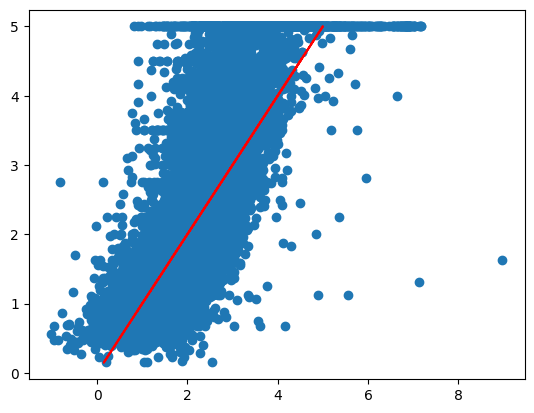

In [184]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')
model.score(X, y)

0.3662918026169407

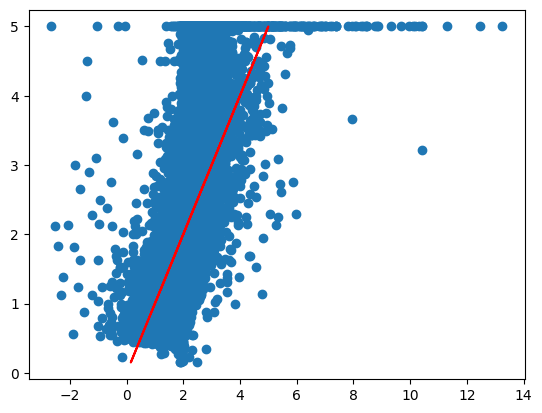

In [185]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5).fit_transform(X)

polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')

polynomial.score(poly, y)

#### 1. Какую еще информацию можно вывести для обученной модели? Попробуйте изменить аргументы при создании модели и посмотрите, как это влияет на качество предсказания.

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [187]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_train = lin_model.predict(X_train)
y_pred_test = lin_model.predict(X_test)

print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("MAE:", mean_absolute_error(y_test, y_pred_test))

Train R2: 0.6125511913966952
Test R2: 0.575787706032451
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
MAE: 0.5332001304956555


In [188]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
print("ridge test r2:", ridge_model.score(X_test, y_test))

ridge test r2: 0.5758549611440126


In [189]:
for a in [0.01, 0.1, 1, 10, 100]:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    print(f"alpha = {a} -> R2 = {model.score(X_test, y_test):.6f}")

alpha = 0.01 -> R2 = 0.575788
alpha = 0.1 -> R2 = 0.575794
alpha = 1 -> R2 = 0.575855
alpha = 10 -> R2 = 0.576437
alpha = 100 -> R2 = 0.580528


#### 2. Попробуйте применить к той же задаче другие модели регрессии. Для каждой из них выведите визуализацию регрессии и оценку точности.

#### Метод опорных векторов:

In [190]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"{name} R2:", r2_score(y_test, y_pred))
    
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, y_pred)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
    plt.title(name)
    plt.xlabel("Real Price")
    plt.ylabel("Predicted Price")
    plt.show()

#### a. без ядра

SVR Linear R2: 0.5579437521813249


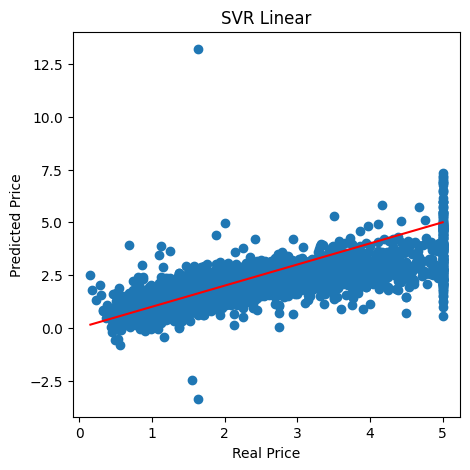

In [191]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svr_linear = make_pipeline(StandardScaler(), SVR(kernel='linear'))
evaluate_model(svr_linear, X_train, X_test, y_train, y_test, "SVR Linear")

#### b. С гауссовым ядром

SVR RBF R2: 0.7275628923016776


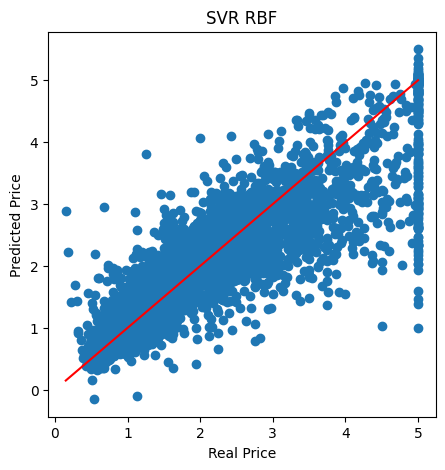

In [192]:
svr_rbf = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
evaluate_model(svr_rbf, X_train, X_test, y_train, y_test, "SVR RBF")

#### c. С полиномиальным ядром

SVR Polynomial R2: 0.23412412991066556


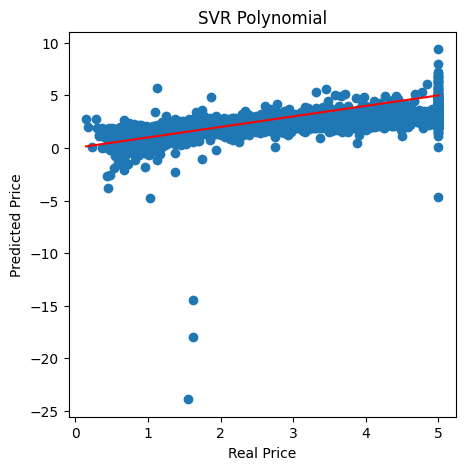

In [193]:
svr_poly = make_pipeline(StandardScaler(), SVR(kernel='poly', degree=3))
evaluate_model(svr_poly, X_train, X_test, y_train, y_test, "SVR Polynomial")

#### Метод ближайших соседей:

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
evaluate_model(knn, X_train, X_test, y_train, y_test, "KNN")

#### Многослойный перцептрон:

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
evaluate_model(mlp, X_train, X_test, y_train, y_test, "MLP")

#### Дерево решений:

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=5, random_state=42)
evaluate_model(tree, X_train, X_test, y_train, y_test, "Decision Tree")

#### Другие:

#### Гребневая регрессия

#### Регрессия Лассо

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
evaluate_model(lasso, X_train, X_test, y_train, y_test, "Lasso")

#### Регрессия ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
evaluate_model(elastic, X_train, X_test, y_train, y_test, "ElasticNet")

#### Случайный лес

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")

#### 3. Напишите функцию, которая автоматически обучает все перечисленные модели и для каждой выдает оценку точности.

In [ ]:
def run_all_models(X_train, X_test, y_train, y_test):
    models = {
        "Linear": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01),
        "ElasticNet": ElasticNet(alpha=0.01),
        "SVR RBF": make_pipeline(StandardScaler(), SVR()),
        "KNN": KNeighborsRegressor(),
        "Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor()
    }
    
    results = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        results[name] = score
    
    return pd.DataFrame(results.items(), columns=["Model", "R2"]).sort_values(by="R2", ascending=False)

run_all_models(X_train, X_test, y_train, y_test)

#### 4. Повтор анализа для датасета diabetes

In [ ]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X_d = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_d = diabetes.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

run_all_models(X_train_d, X_test_d, y_train_d, y_test_d)